# Parkinson's Disease Detection from Speech Signals

Binary classification of Parkinson's Disease (PD) vs. healthy controls using acoustic features extracted from sustained vowel phonation.

**Dataset:** [UCI Parkinson's Disease Classification Data Set](https://archive.ics.uci.edu/ml/datasets/Parkinson%27s+Disease+Classification) (Sakar et al., 2019) — 756 voice recordings (3 repetitions each) from 252 subjects (188 PD patients, 64 healthy controls), with 754 acoustic features per recording (jitter, shimmer, MFCCs, wavelet-based measures, etc.).

**Goal:** build a properly validated classification pipeline and compare several algorithms — without leaking information between train and test.

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score

sns.set_style('whitegrid')
RANDOM_STATE = 42

## 2. Data Loading & Overview

In [2]:
data = pd.read_csv('pd_speech_features.csv')
print("Shape:", data.shape)
data.head()

Shape: (756, 755)


,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240.0,239.0,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234.0,233.0,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232.0,231.0,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178.0,177.0,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236.0,235.0,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


In [3]:
data['class'].value_counts()

class
1    564
0    192
Name: count, dtype: int64

**Important structural detail:** each subject was recorded 3 times, so the 756 rows correspond to only **252 unique subjects** (identified by `id`), not 756 independent samples.

In [4]:
print("Unique subjects:", data['id'].nunique())
print("Recordings per subject:")
print(data['id'].value_counts().value_counts())

Unique subjects: 252
Recordings per subject:
count
3    252
Name: count, dtype: int64


This matters a lot for validation: recordings from the same subject are highly correlated (same voice, same physiology). If a random row-level train/test split lets recordings from one subject land in *both* train and test, the model can partly "recognize the subject" rather than learn genuine disease signal — inflating reported accuracy. Every split and cross-validation fold in this notebook is therefore done **by subject (`id`), not by row**, using `GroupShuffleSplit` / `StratifiedGroupKFold`.

## 3. Data Cleaning

### 3.1 Duplicate rows

In [5]:
print("Duplicate rows:", data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)

Duplicate rows: 1


### 3.2 Corrupted numeric columns

Two columns that should be numeric were read in as strings because of single corrupted entries (a stray `#` and a stray `a` inside otherwise valid floats).

In [6]:
for col in ['locDbShimmer', 'maxIntensity']:
    bad = [v for v in data[col] if not str(v).replace('.', '', 1).replace('-', '', 1).isdigit()]
    print(col, '-> bad values:', bad)

locDbShimmer -> bad values: ['1.13#4', nan]
maxIntensity -> bad values: ['66.13744a406', nan]


In [7]:
data['locDbShimmer'] = data['locDbShimmer'].replace('1.13#4', '1.134').astype(float)
data['maxIntensity'] = data['maxIntensity'].replace('66.13744a406', '66.13744406').astype(float)

### 3.3 Missing values

One column, `det_LT_TKEO_std_6_coef`, is missing for the large majority of rows — too sparse to impute meaningfully, so it's dropped. The remaining missing values are concentrated almost entirely in two rows that are corrupted across most of their columns; those rows are dropped along with a handful of isolated single-cell nulls.

In [8]:
null_counts = data.isna().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
print(f"{len(null_counts)} columns have at least one null; the worst is:")
print(null_counts.head(3))

195 columns have at least one null; the worst is:
det_LT_TKEO_std_6_coef        533
ppq5Jitter                      2
meanNoiseToHarmHarmonicity      2
dtype: int64


In [9]:
data = data.drop(columns=['det_LT_TKEO_std_6_coef'])

row_nulls = data.isna().sum(axis=1)
print("Rows with any remaining null:")
print(row_nulls[row_nulls > 0])

data = data.dropna().reset_index(drop=True)
print("\nShape after cleaning:", data.shape)
print("Subjects remaining:", data['id'].nunique())

Rows with any remaining null:
22       1
45       1
82       1
151    193
219    155
dtype: int64



Shape after cleaning: (750, 754)
Subjects remaining: 252


**Note on the original version of this notebook:** it also removed statistical outliers from three columns (`RPDE`, `DFA`, `numPulses`) using IQR bounds computed on the *entire* dataset, and engineered a `SignalType` feature from an unvalidated custom formula. Both were dropped here — the IQR bounds were a source of train/test leakage (computed using rows that later end up in the test set), and the engineered feature's formula/thresholds had no stated justification. Simpler and more defensible to leave those out.

## 4. Exploratory Data Analysis

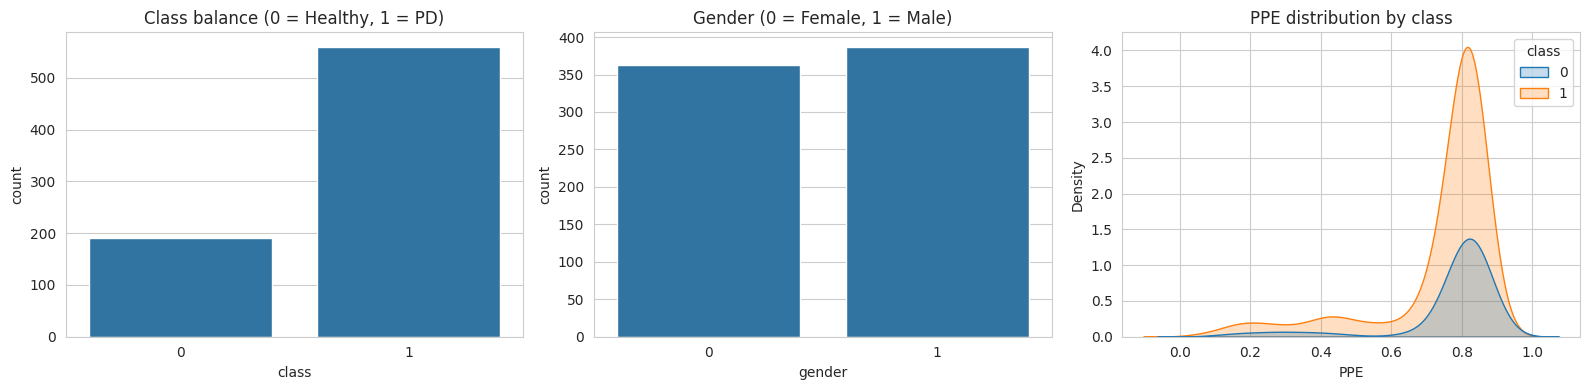

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(x='class', data=data, ax=axes[0])
axes[0].set_title('Class balance (0 = Healthy, 1 = PD)')
sns.countplot(x='gender', data=data, ax=axes[1])
axes[1].set_title('Gender (0 = Female, 1 = Male)')
sns.kdeplot(data=data, x='PPE', hue='class', fill=True, ax=axes[2])
axes[2].set_title('PPE distribution by class')
plt.tight_layout()
plt.show()

The dataset is imbalanced (~3:1 PD to healthy), which is why **balanced accuracy** and **macro F1** are tracked alongside plain accuracy throughout, and why `class_weight='balanced'` is used in the models below.

## 5. Train / Test Split (grouped by subject)

In [11]:
groups = data['id']
y = data['class']
X = data.drop(columns=['id', 'class'])

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

print(f"Train: {X_train.shape[0]} recordings from {groups_train.nunique()} subjects")
print(f"Test:  {X_test.shape[0]} recordings from {groups.iloc[test_idx].nunique()} subjects")
print("Subject overlap between train and test:", set(groups_train) & set(groups.iloc[test_idx]))

Train: 598 recordings from 201 subjects
Test:  152 recordings from 51 subjects
Subject overlap between train and test: set()


## 6. Model Comparison (Pipeline + Grouped Cross-Validation)

Each model is wrapped in a `Pipeline` (`StandardScaler` → `SelectKBest` → classifier) so that scaling and feature selection are refit on every training fold — nothing about the validation fold ever leaks into preprocessing. Cross-validation uses `StratifiedGroupKFold`, which keeps class balance stable across folds *and* guarantees no subject appears in more than one fold.

Four algorithms are compared (matching the approach from the Sonar/Rock-vs-Mine project) across a few feature-selection sizes to check whether the full 752-feature space, or a reduced one, works better.

In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=7, class_weight='balanced', random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=5),
}

scoring = {'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'f1_macro': 'f1_macro'}
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
k_options = [50, 100, 200, 'all']

results = []
for k in k_options:
    for name, clf in models.items():
        steps = [('scaler', StandardScaler())]
        if k != 'all':
            steps.append(('select', SelectKBest(f_classif, k=k)))
        steps.append(('model', clf))
        pipe = Pipeline(steps)

        scores = cross_validate(pipe, X_train, y_train, groups=groups_train, cv=cv, scoring=scoring)
        results.append({
            'k_features': k,
            'model': name,
            'accuracy': scores['test_accuracy'].mean(),
            'balanced_accuracy': scores['test_balanced_accuracy'].mean(),
            'f1_macro': scores['test_f1_macro'].mean(),
        })

results_df = pd.DataFrame(results).sort_values('f1_macro', ascending=False).reset_index(drop=True)
results_df.round(3)

,k_features,model,accuracy,balanced_accuracy,f1_macro
0,50,Random Forest,0.831,0.722,0.742
1,all,Random Forest,0.833,0.712,0.739
2,all,KNN,0.826,0.712,0.733
3,200,Random Forest,0.824,0.708,0.732
4,100,Random Forest,0.814,0.697,0.717
5,200,SVM (RBF),0.776,0.722,0.708
6,all,SVM (RBF),0.791,0.691,0.702
7,all,Logistic Regression,0.769,0.695,0.694
8,200,KNN,0.787,0.680,0.690
9,100,SVM (RBF),0.749,0.713,0.688


**Random Forest with the top 50 features (by ANOVA F-value) gives the best cross-validated macro F1 and balanced accuracy**, and is essentially tied with using all 752 features — so the smaller, more interpretable feature set is preferred. This becomes the final pipeline.

## 7. Final Model: Fit & Evaluate on Held-Out Subjects

In [13]:
best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(f_classif, k=50)),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=7, class_weight='balanced', random_state=RANDOM_STATE))
])

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

print(f"Test accuracy:          {best_pipeline.score(X_test, y_test):.3f}")
print(f"Test balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'PD (1)']))

Test accuracy:          0.789
Test balanced accuracy: 0.685

              precision    recall  f1-score   support

 Healthy (0)       0.68      0.45      0.54        42
      PD (1)       0.81      0.92      0.86       110

    accuracy                           0.79       152
   macro avg       0.75      0.69      0.70       152
weighted avg       0.78      0.79      0.77       152



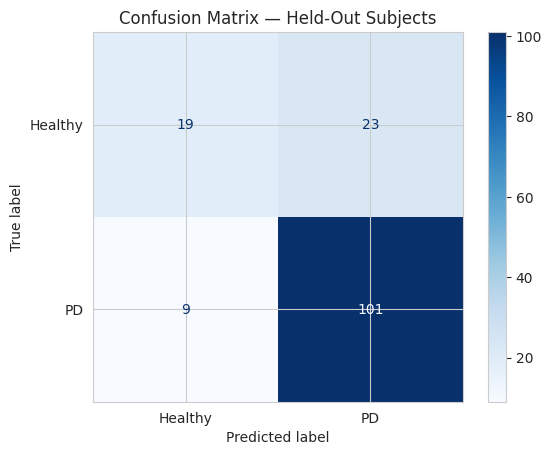

In [14]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'PD'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Held-Out Subjects')
plt.show()

The held-out test set has only 51 subjects (152 recordings), so this single-split evaluation is noisier than the 5-fold CV estimate above — it's reported as a final sanity check on genuinely unseen subjects, not as the headline number. The CV results in Section 6 are the more reliable performance estimate.

## 8. Feature Importance

Which of the 50 selected features the Random Forest actually relies on:

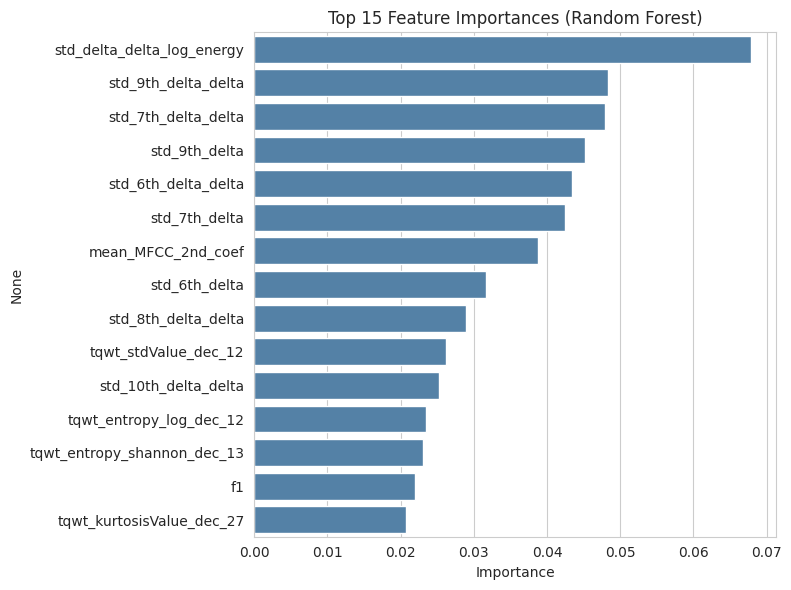

In [15]:
selected_mask = best_pipeline.named_steps['select'].get_support()
selected_features = X_train.columns[selected_mask]
importances = best_pipeline.named_steps['model'].feature_importances_

top_features = pd.Series(importances, index=selected_features).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_features.values, y=top_features.index, color='steelblue')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 9. Save the Final Model

In [16]:
joblib.dump(best_pipeline, 'pd_speech_rf_pipeline.joblib')
print("Saved pipeline to pd_speech_rf_pipeline.joblib")

Saved pipeline to pd_speech_rf_pipeline.joblib


## 10. Conclusions & Limitations

- **Best pipeline:** `StandardScaler → SelectKBest(f_classif, k=50) → RandomForestClassifier`, chosen by 5-fold `StratifiedGroupKFold` cross-validation (macro F1 ≈ 0.74, balanced accuracy ≈ 0.72).
- **Why grouped validation matters:** with 3 recordings per subject, a naive row-level split would let the model partially "memorize" subjects rather than learn disease-related acoustic patterns, inflating every metric. All splits here are subject-disjoint.
- **Class imbalance (~3:1):** addressed with `class_weight='balanced'` and by reporting balanced accuracy / macro F1 rather than relying on plain accuracy.
- **Limitations:**
  - Held-out test set is small (51 subjects) — the single-split numbers in Section 7 carry real sampling noise; the CV estimate is more trustworthy.
  - No hyperparameter tuning was performed (fixed, reasonable defaults were used for each model) — a `GridSearchCV`/`RandomizedSearchCV` with the same grouped CV scheme would likely improve on these numbers.
  - This is a small, single-source dataset (one recording protocol, one clinic) — it is a methodology demonstration, **not a validated diagnostic tool**.